# Association Rule Mining using Apriori and FP-Tree algorithms

## Overview

Association rule mining is used to discover relationships between items that frequently occur together in the same transaction. A classic example is market basket analysis: if customers often buy item A and item B together, a retailer may use that relationship for recommendations, product placement, or promotions.

This notebook compares two algorithms for discovering frequent itemsets:

- **Apriori**: repeatedly generates candidate itemsets and tests whether they are frequent.
- **FP-Growth**: compresses the transaction database into a dense structure called the FP-tree and mines frequent patterns without explicitly generating the same large candidate sets.

The overall workflow is:

1. Load and clean the retail transactions.
2. Convert invoices into baskets of products.
3. One-hot encode those baskets.
4. Mine frequent itemsets with Apriori and FP-Growth.
5. Generate association rules from the frequent itemsets.
6. Compare the algorithms in terms of results and execution time.
7. Interpret the most interesting rules using support, confidence, and lift.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("online_retail.parquet")

print(f"dataset shape: {df.shape}")
df.head()

dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26:00,3.39,17850.0,United Kingdom


## Data cleaning

The raw Online Retail data contains cancellations, missing customer identifiers, non-positive quantities/prices, and inconsistent whitespace in product descriptions. These records can distort further work, so they are removed or normalized before constructing transactions.

We also remove products that occur fewer than five times. This is done because rare products are unlikely to produce useful frequent patterns and can increase the size of the search space.

The resulting data is still transaction-level data, as each `InvoiceNo` represents one basket, and the product descriptions belonging to that invoice form its items.


In [2]:
# Keep only invoices that do not start with 'C' (rest are negative quantities)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# remove rules without any customer ID
df = df.dropna(subset=["CustomerID"])

# remove any quantities that are negative or zero
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# clean up descriptions
df["Description"] = df["Description"].str.strip()

# filter out low volume items (items that appear less than five times)
item_counts = df['Description'].value_counts()
items_to_keep = item_counts[item_counts >= 5].index
df = df[df['Description'].isin(items_to_keep)]

print(f"shape after cleaning: {df.shape}")

shape after cleaning: (396661, 8)


## Building the transaction database

Association rule mining expects the data in the form of `transaction -> itemsets`.

For example:

```text
Invoice 10001 -> {Bread, Milk, Eggs}
Invoice 10002 -> {Milk, Coffee}
Invoice 10003 -> {Bread, Milk}
```

Here, an invoice is treated as one transaction. The order of items inside a transaction does not matter; what matters is whether an item is present in the basket.


In [3]:
# Group by InvoiceNo and collect all items (Descriptions) in each basket
basket = df.groupby('InvoiceNo')['Description'].apply(list).reset_index()

# Convert to a list of lists
transactions = basket['Description'].tolist()

print(f"Total number of transactions: {len(transactions)}")
print(f"Example transaction: {transactions[0][:5]}...")  # show first 5 items

Total number of transactions: 18516
Example transaction: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.']...


## One-hot encoding

`mlxtend`'s `TransactionEncoder` converts the list-of-lists representation into a Boolean matrix:

| Transaction | Bread | Milk | Eggs | Coffee |
|---|---:|---:|---:|---:|
| 10001 | 1 | 1 | 1 | 0 |
| 10002 | 0 | 1 | 0 | 1 |
| 10003 | 1 | 1 | 0 | 0 |

A value of `1` means that the item occurs in that transaction. This representation lets the frequent-itemset algorithms efficiently calculate how often item combinations occur.


In [4]:
# one-hot encoding for the transactions

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(df_encoded.shape)  # (num_transactions, num_unique_items)
df_encoded.head()

(18516, 3293)


,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


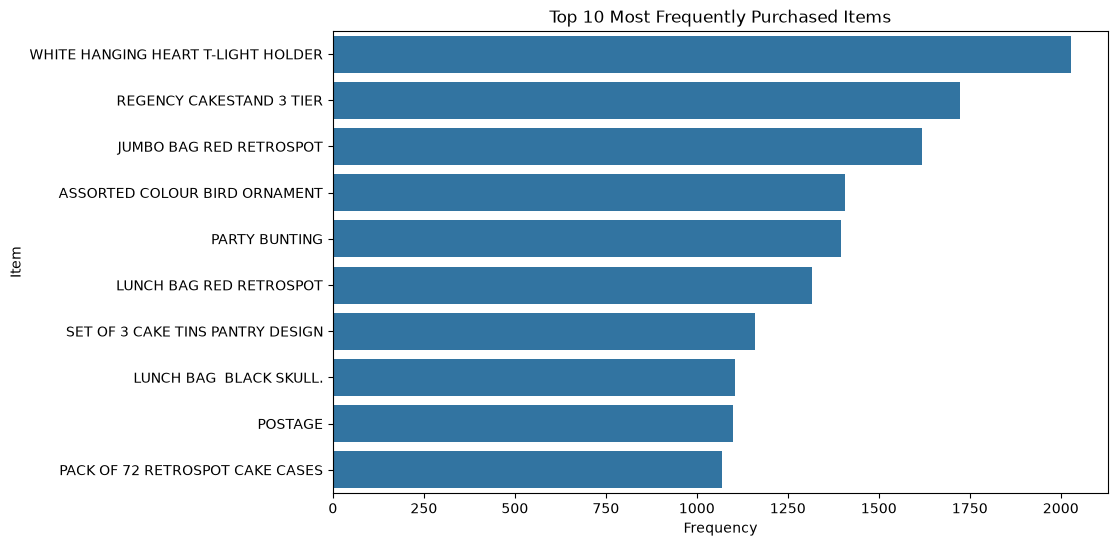

In [5]:
# view the top 10 most frequent items
from collections import Counter

all_items = [item for sublist in transactions for item in sublist]
item_freq = Counter(all_items).most_common(10)

top_items_df = pd.DataFrame(item_freq, columns=['Item', 'Frequency'])
plt.figure(figsize=(10,6))
sns.barplot(data=top_items_df, x='Frequency', y='Item')
plt.title('Top 10 Most Frequently Purchased Items')
plt.show()

## Apriori

Apriori is based on the Apriori principle, which states:

> If an itemset is frequent, every non-empty subset of that itemset must also be frequent.

The algorithm therefore works level by level:

1. Find frequent 1-itemsets.
2. Use them to generate candidate 2-itemsets.
3. Count their support and keep only the frequent ones.
4. Use the frequent 2-itemsets to generate candidate 3-itemsets.
5. Continue until no more frequent itemsets can be generated.

This pruning strategy avoids testing every possible item combination, but candidate generation can still become expensive when the number of items or the number of frequent patterns is large.

### Minimum support

Here we use:

$$
\mathrm{Support}(X) = \frac{\text{transactions containing }X}{\text{total transactions}}
$$

With `min_support = 0.01`, an itemset must occur in at least 1% of all transactions to be considered frequent.


## From frequent itemsets to association rules

A frequent itemset such as

```text
{A, B, C}
```

can be turned into rules such as

```text
{A, B} -> {C}
{A, C} -> {B}
{B, C} -> {A}
```

The itemset to the left of the rule is called the antecedent, and the itemset to the right is called the
consequent.

Three metrics are especially useful when interpreting these rules:

### Support

$$
\mathrm{Support}(A \rightarrow B) = P(A \cup B)
$$

It measures how common the complete combination is in the dataset.

### Confidence

$$
\mathrm{Confidence}(A \rightarrow B) = P(B \mid A)
$$

It measures how often a transaction containing the antecedent also contains the consequent.

A confidence of `0.50`, for example, means that 50% of the transactions containing the antecedent also contain the consequent.

### Lift

$$
\mathrm{Lift}(A \rightarrow B) = \frac{P(B\mid A)}{P(B)}
$$

Lift compares the rule against what we would expect if the antecedent and consequent were independent.

- Lift > 1: positive association.
- Lift ≈ 1: little evidence of association beyond chance.
- Lift < 1: negative association.

For this reason, high lift is often more informative than confidence alone. A very popular product can produce high-confidence rules simply because the consequent appears in many transactions.


In [6]:
from mlxtend.frequent_patterns import apriori

# Min support = 1% of transactions
min_support = 0.01

frequent_itemsets_apriori = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Add a column for the length of each itemset
frequent_itemsets_apriori['length'] = frequent_itemsets_apriori['itemsets'].apply(len)

print(f"Number of frequent itemsets found: {len(frequent_itemsets_apriori)}")
frequent_itemsets_apriori.head(10)

Number of frequent itemsets found: 973


,support,itemsets,length
0,0.013070,frozenset({10 COLOUR SPACEBOY PEN}),1
1,0.010099,frozenset({12 MESSAGE CARDS WITH ENVELOPES}),1
2,0.014906,frozenset({12 PENCIL SMALL TUBE WOODLAND}),1
3,0.016580,frozenset({12 PENCILS SMALL TUBE RED RETROSPOT}),1
4,0.015716,frozenset({12 PENCILS SMALL TUBE SKULL}),1
5,0.012638,frozenset({12 PENCILS TALL TUBE RED RETROSPOT}),1
6,0.011612,frozenset({12 PENCILS TALL TUBE SKULLS}),1
7,0.011234,frozenset({12 PENCILS TALL TUBE WOODLAND}),1
8,0.011558,frozenset({15CM CHRISTMAS GLASS BALL 20 LIGHTS}),1
9,0.010045,frozenset({3 DRAWER ANTIQUE WHITE WOOD CABINET}),1


In [7]:
# generate association rules

from mlxtend.frequent_patterns import association_rules

# Min confidence threshold, e.g., 0.5 (50%)
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.5)

# Sort by lift to see the most interesting rules
rules_apriori = rules_apriori.sort_values('lift', ascending=False)

print(f"Number of rules generated: {len(rules_apriori)}")
rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Number of rules generated: 275


,antecedents,consequents,support,confidence,lift
106,frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE PINK}),0.010909,0.748148,61.842460
107,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN}),0.010909,0.901786,61.842460
258,"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),0.010045,0.732283,53.805399
259,frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S ...",0.010045,0.738095,53.805399
100,frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.011126,0.757353,52.325176
101,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.011126,0.768657,52.325176
257,"frozenset({POPPY'S PLAYHOUSE LIVINGROOM, POPPY...",frozenset({POPPY'S PLAYHOUSE BEDROOM}),0.010045,0.865116,50.691434
260,frozenset({POPPY'S PLAYHOUSE BEDROOM}),"frozenset({POPPY'S PLAYHOUSE LIVINGROOM, POPPY...",0.010045,0.588608,50.691434
111,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES}),0.010639,0.879464,49.646831
110,frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY TEA PLATE PINK}),0.010639,0.600610,49.646831


## FP-Growth

FP-Growth takes a different approach from Apriori.

Instead of repeatedly generating candidate itemsets, it:

1. Counts item frequencies.
2. Builds a compact Frequent Pattern Tree (FP-tree) from the transactions.
3. Recursively mines the tree to obtain frequent itemsets.

The idea is that many transactions share prefixes. The FP-tree stores those shared prefixes compactly, reducing the amount of repeated database scanning and candidate generation.

This often makes FP-Growth substantially faster than Apriori, particularly on datasets with many items or many frequent patterns.

One point to keep in mind is that FP-Growth is not expected to produce different frequent itemsets just because the algorithm is different. With the same data and support threshold, it should identify the same set of frequent itemsets.


## FP-Growth

In [8]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets_fpgrowth = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)

# Add length column
frequent_itemsets_fpgrowth['length'] = frequent_itemsets_fpgrowth['itemsets'].apply(len)

print(f"FP-Growth found {len(frequent_itemsets_fpgrowth)} frequent itemsets.")
frequent_itemsets_fpgrowth.head(10)

FP-Growth found 973 frequent itemsets.


,support,itemsets,length
0,0.106448,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
1,0.017336,frozenset({RED WOOLLY HOTTIE WHITE HEART.}),1
2,0.017228,frozenset({KNITTED UNION FLAG HOT WATER BOTTLE}),1
3,0.016040,frozenset({SET 7 BABUSHKA NESTING BOXES}),1
4,0.013016,frozenset({CREAM CUPID HEARTS COAT HANGER}),1
5,0.012854,frozenset({WHITE METAL LANTERN}),1
6,0.023817,frozenset({HAND WARMER UNION JACK}),1
7,0.074260,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
8,0.037319,frozenset({HOME BUILDING BLOCK WORD}),1
9,0.029974,frozenset({LOVE BUILDING BLOCK WORD}),1


In [9]:
# generate rules
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=0.5)
rules_fpgrowth = rules_fpgrowth.sort_values('lift', ascending=False)

print(f"FP-Growth generated {len(rules_fpgrowth)} rules.")
rules_fpgrowth[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

FP-Growth generated 275 rules.


,antecedents,consequents,support,confidence,lift
258,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE GREEN}),0.010909,0.901786,61.842460
257,frozenset({REGENCY TEA PLATE GREEN}),frozenset({REGENCY TEA PLATE PINK}),0.010909,0.748148,61.842460
172,"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S ...",frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),0.010045,0.732283,53.805399
173,frozenset({POPPY'S PLAYHOUSE LIVINGROOM}),"frozenset({POPPY'S PLAYHOUSE BEDROOM, POPPY'S ...",0.010045,0.738095,53.805399
254,frozenset({REGENCY SUGAR BOWL GREEN}),frozenset({REGENCY MILK JUG PINK}),0.011126,0.768657,52.325176
253,frozenset({REGENCY MILK JUG PINK}),frozenset({REGENCY SUGAR BOWL GREEN}),0.011126,0.757353,52.325176
171,"frozenset({POPPY'S PLAYHOUSE LIVINGROOM, POPPY...",frozenset({POPPY'S PLAYHOUSE BEDROOM}),0.010045,0.865116,50.691434
174,frozenset({POPPY'S PLAYHOUSE BEDROOM}),"frozenset({POPPY'S PLAYHOUSE LIVINGROOM, POPPY...",0.010045,0.588608,50.691434
260,frozenset({REGENCY TEA PLATE PINK}),frozenset({REGENCY TEA PLATE ROSES}),0.010639,0.879464,49.646831
259,frozenset({REGENCY TEA PLATE ROSES}),frozenset({REGENCY TEA PLATE PINK}),0.010639,0.600610,49.646831


## Comparing the algorithms

There are two separate questions here:

### 1. Do they produce the same patterns?

Because both algorithms are solving the same frequent-itemset mining problem, their frequent itemsets should match when the preprocessing and support threshold are identical. The equality check below verifies this directly.

### 2. Which algorithm is faster?

The timing comparison measures how long each algorithm takes to mine the same encoded dataset.

In general, Apriori spends more work on candidate generation and support counting, while FP-Growth avoids explicit candidate generation by mining the FP-tree. Therefore, FP-Growth is usually faster.

## Comparison

In [10]:
# performance comparison (as in execution time)
import time

# Time Apriori
start = time.time()
apriori(df_encoded, min_support=0.01, use_colnames=True)
apriori_time = time.time() - start

# Time FP-Growth
start = time.time()
fpgrowth(df_encoded, min_support=0.01, use_colnames=True)
fpgrowth_time = time.time() - start

print(f"Apriori execution time: {apriori_time:.4f} seconds")
print(f"FP-Growth execution time: {fpgrowth_time:.4f} seconds")

Apriori execution time: 7.2221 seconds
FP-Growth execution time: 1.4422 seconds


In [11]:
# make sure both produce same rules for same support
# Check if the number of frequent itemsets is identical
print(f"Apriori itemsets: {len(frequent_itemsets_apriori)}")
print(f"FP-Growth itemsets: {len(frequent_itemsets_fpgrowth)}")

# Check if the sets are actually the same (convert frozensets to sorted tuples for comparison)
apriori_set = set(frozenset(i) for i in frequent_itemsets_apriori['itemsets'])
fpgrowth_set = set(frozenset(i) for i in frequent_itemsets_fpgrowth['itemsets'])
print(f"Are the itemsets identical? {apriori_set == fpgrowth_set}")

Apriori itemsets: 973
FP-Growth itemsets: 973
Are the itemsets identical? True


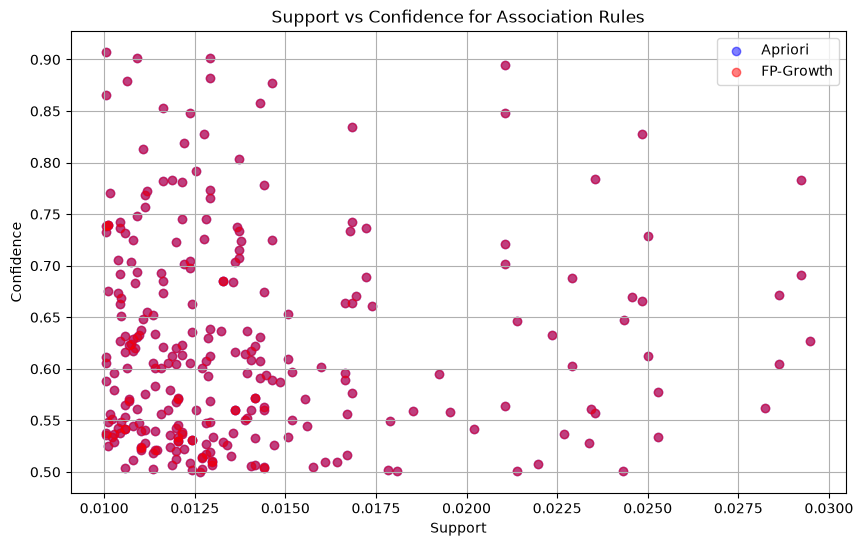

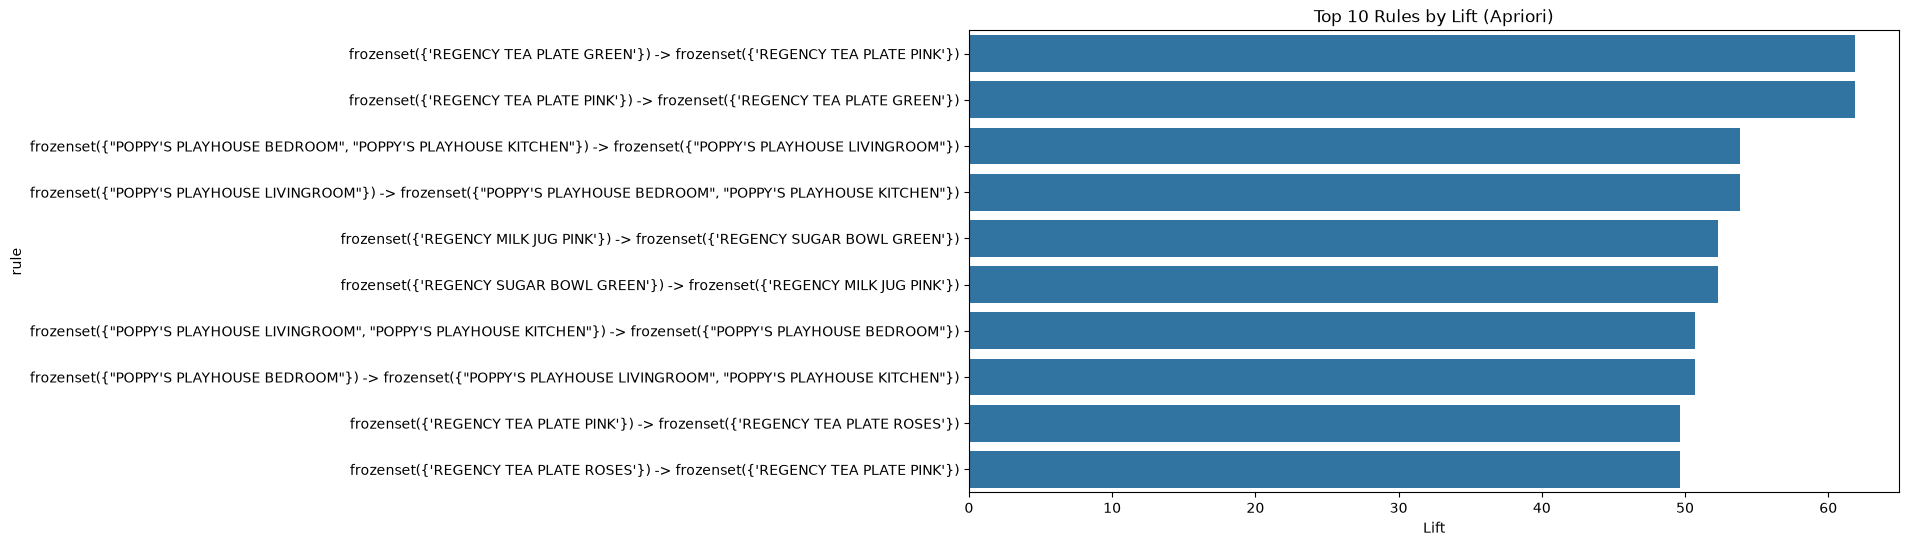

In [12]:
# Scatter plot: Support vs Confidence
plt.figure(figsize=(10,6))
plt.scatter(rules_apriori['support'], rules_apriori['confidence'], alpha=0.5, c='blue', label='Apriori')
plt.scatter(rules_fpgrowth['support'], rules_fpgrowth['confidence'], alpha=0.5, c='red', label='FP-Growth')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence for Association Rules')
plt.legend()
plt.grid(True)
plt.show()

# Top 10 rules by Lift (bar plot)
top_rules = rules_apriori.head(10).copy()
top_rules['rule'] = top_rules['antecedents'].astype(str) + " -> " + top_rules['consequents'].astype(str)

plt.figure(figsize=(12,6))
sns.barplot(data=top_rules, x='lift', y='rule')
plt.title('Top 10 Rules by Lift (Apriori)')
plt.xlabel('Lift')
plt.show()


## Interpreting the results

The results tell us the following:

- The two frequent-itemset counts are equal and the set comparison returns `True`, hence the two algorithms are functionally equivalent.
- The FP-Growth runtime is significantly lower than the Apriori runtime, hence this dataset provides an empirical example of the computational advantage of FP-Growth.
- The scatter plot further shows that the two algorithms produce the same rules, as all points coincide between the two.

For example, a rule with high confidence but lift close to `1` may not represent a particularly interesting relationship. A rule with high lift but extremely low support may be statistically interesting while affecting very few transactions. Good rules balance these measures with the practical goal of the analysis.


## Conclusion

Apriori and FP-Growth can discover the same frequent itemsets, but they use different search strategies.

- Apriori: candidate generation + pruning using the Apriori principle.
- FP-Growth: compact FP-tree representation + recursive pattern mining.
- Association rules: evaluated using support, confidence, and lift.
- Practical comparison: verify that both algorithms return the same patterns, then compare their execution time on the same dataset.